# ADF test

This notebook illustrates the Augmented Dickey-Fuller (ADF) test with crypto data downloaded through `vectorbt`.

The main idea is simple:

- raw prices of major crypto assets often behave like non-stationary series;
- returns are usually much closer to stationary;
- a spread or detrended series is a more natural candidate for mean reversion.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

repo_root = find_repo_root()
fixture_path = repo_root / "fixtures/crypto/crypto_daily_close.csv"

close_matrix = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close_matrix = close_matrix.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbol = "BTCUSDT"
if symbol not in close_matrix:
    raise ValueError(f"Fixture is missing required symbol: {symbol}")

close = close_matrix[symbol].dropna()
close.name = "close"
close.tail()


In [3]:
log_price = np.log(close)
log_return = log_price.diff().dropna()

# A simple detrended series: distance from a 30-day rolling mean.
# This is not a tradable spread by itself, but it is useful to show how
# mean-reverting candidates differ from raw prices under the ADF test.
rolling_mean = log_price.rolling(30).mean()
demeaned_30d = (log_price - rolling_mean).dropna()

series_dict = {
    "BTC close": close,
    "BTC log price": log_price.dropna(),
    "BTC log return": log_return,
    "BTC log price minus 30d mean": demeaned_30d,
}

pd.DataFrame({name: s.tail(3) for name, s in series_dict.items()})

,BTC close,BTC log price,BTC log return,BTC log price minus 30d mean
date,,,,
2024-06-28,"60,427.840000",11.009205,-0.020939,-0.092170
2024-06-29,"60,986.680000",11.018411,0.009206,-0.079164
2024-06-30,"62,772.010000",11.047265,0.028854,-0.047870


,BTC close,BTC log price,BTC log return,BTC log price minus 30d mean
date,,,,
2024-06-28,"60,427.840000",11.009205,-0.020939,-0.092170
2024-06-29,"60,986.680000",11.018411,0.009206,-0.079164
2024-06-30,"62,772.010000",11.047265,0.028854,-0.047870


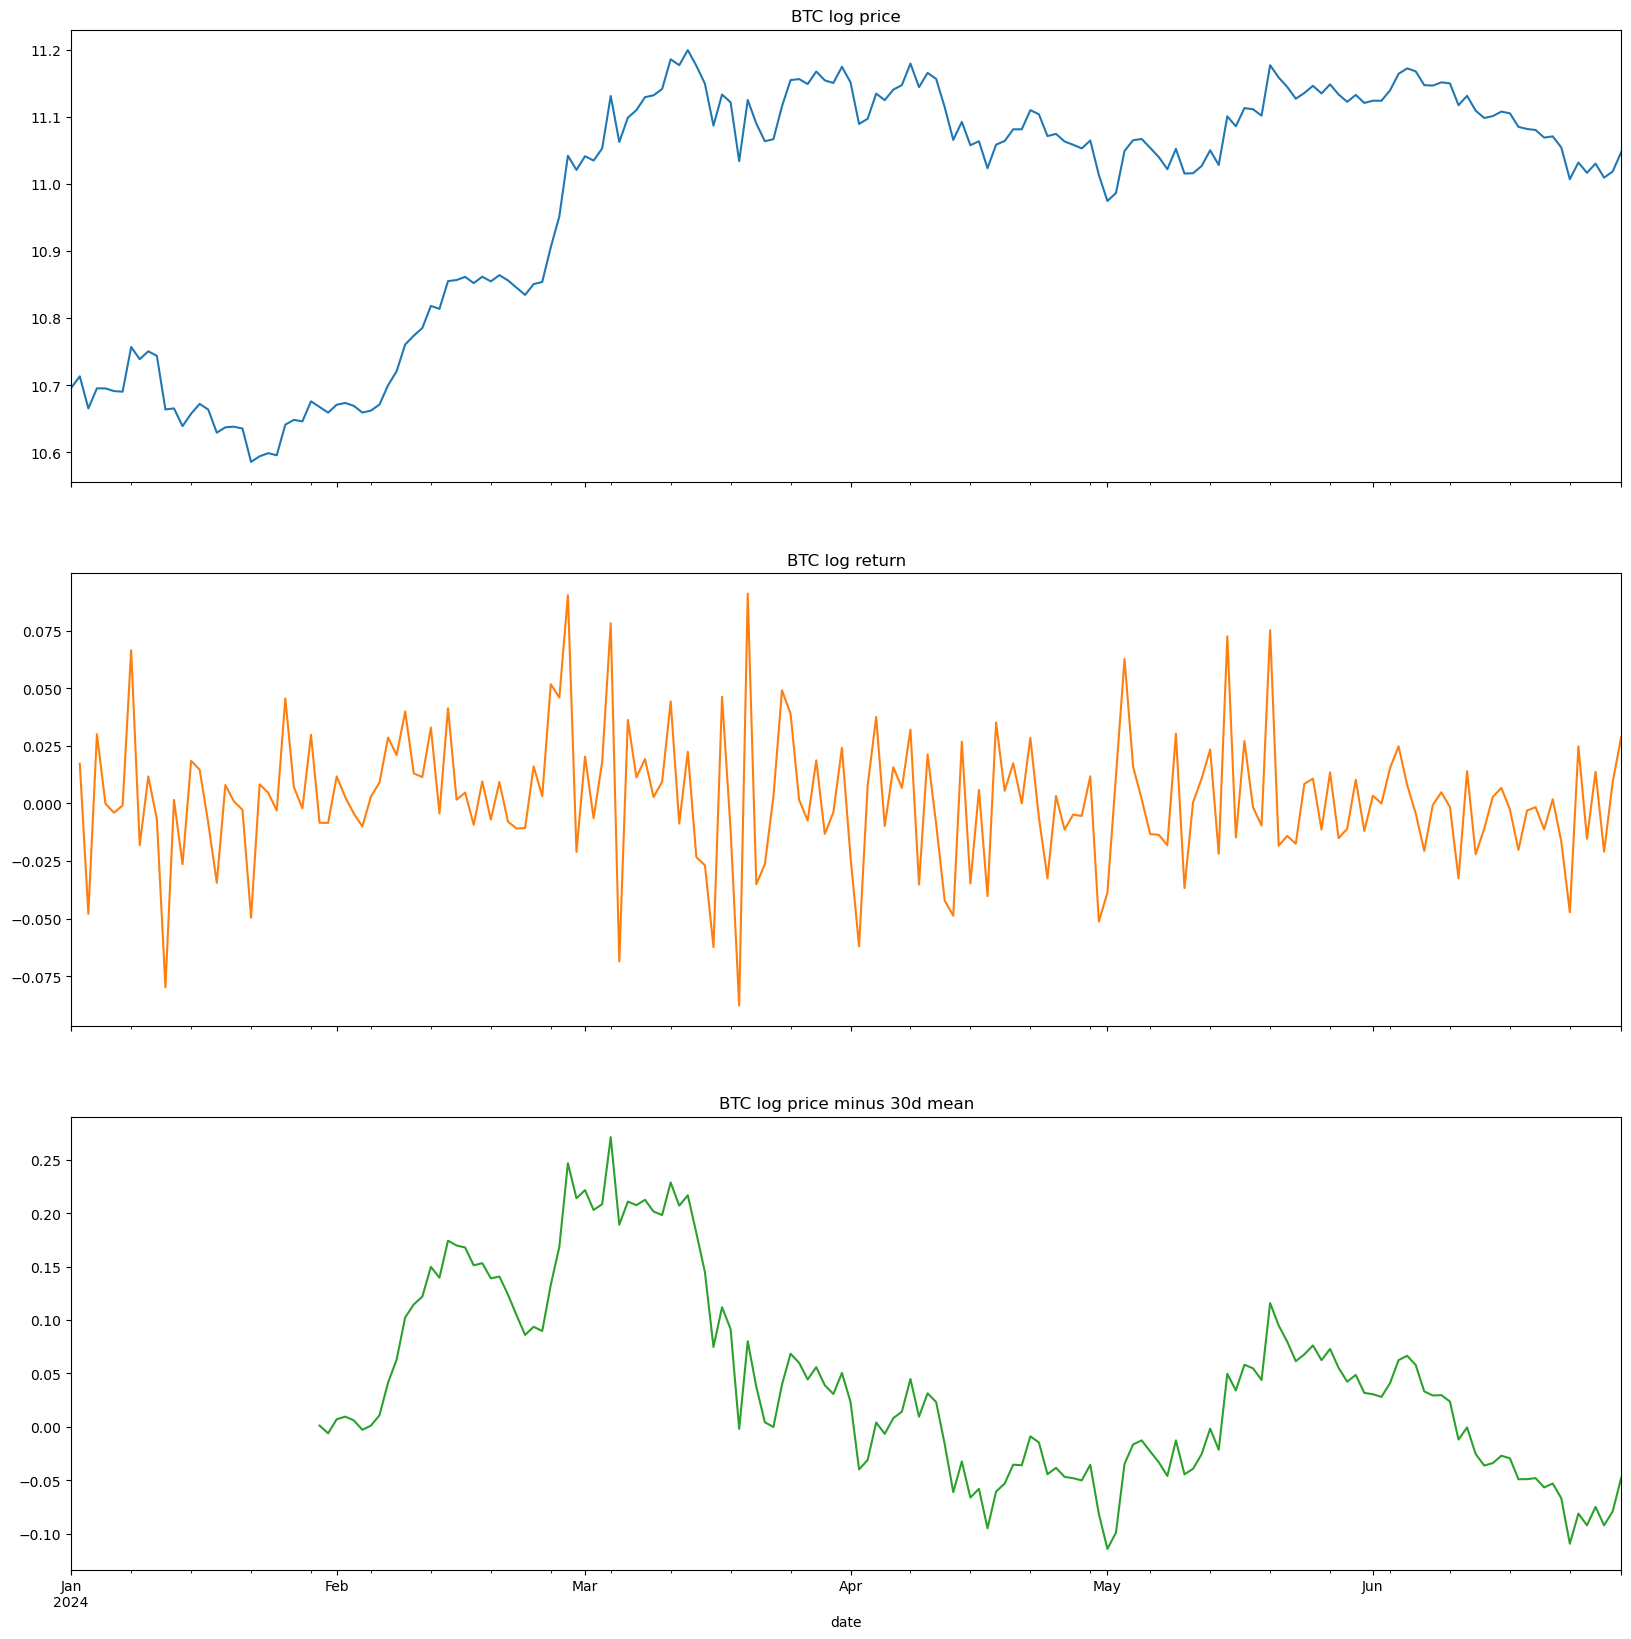

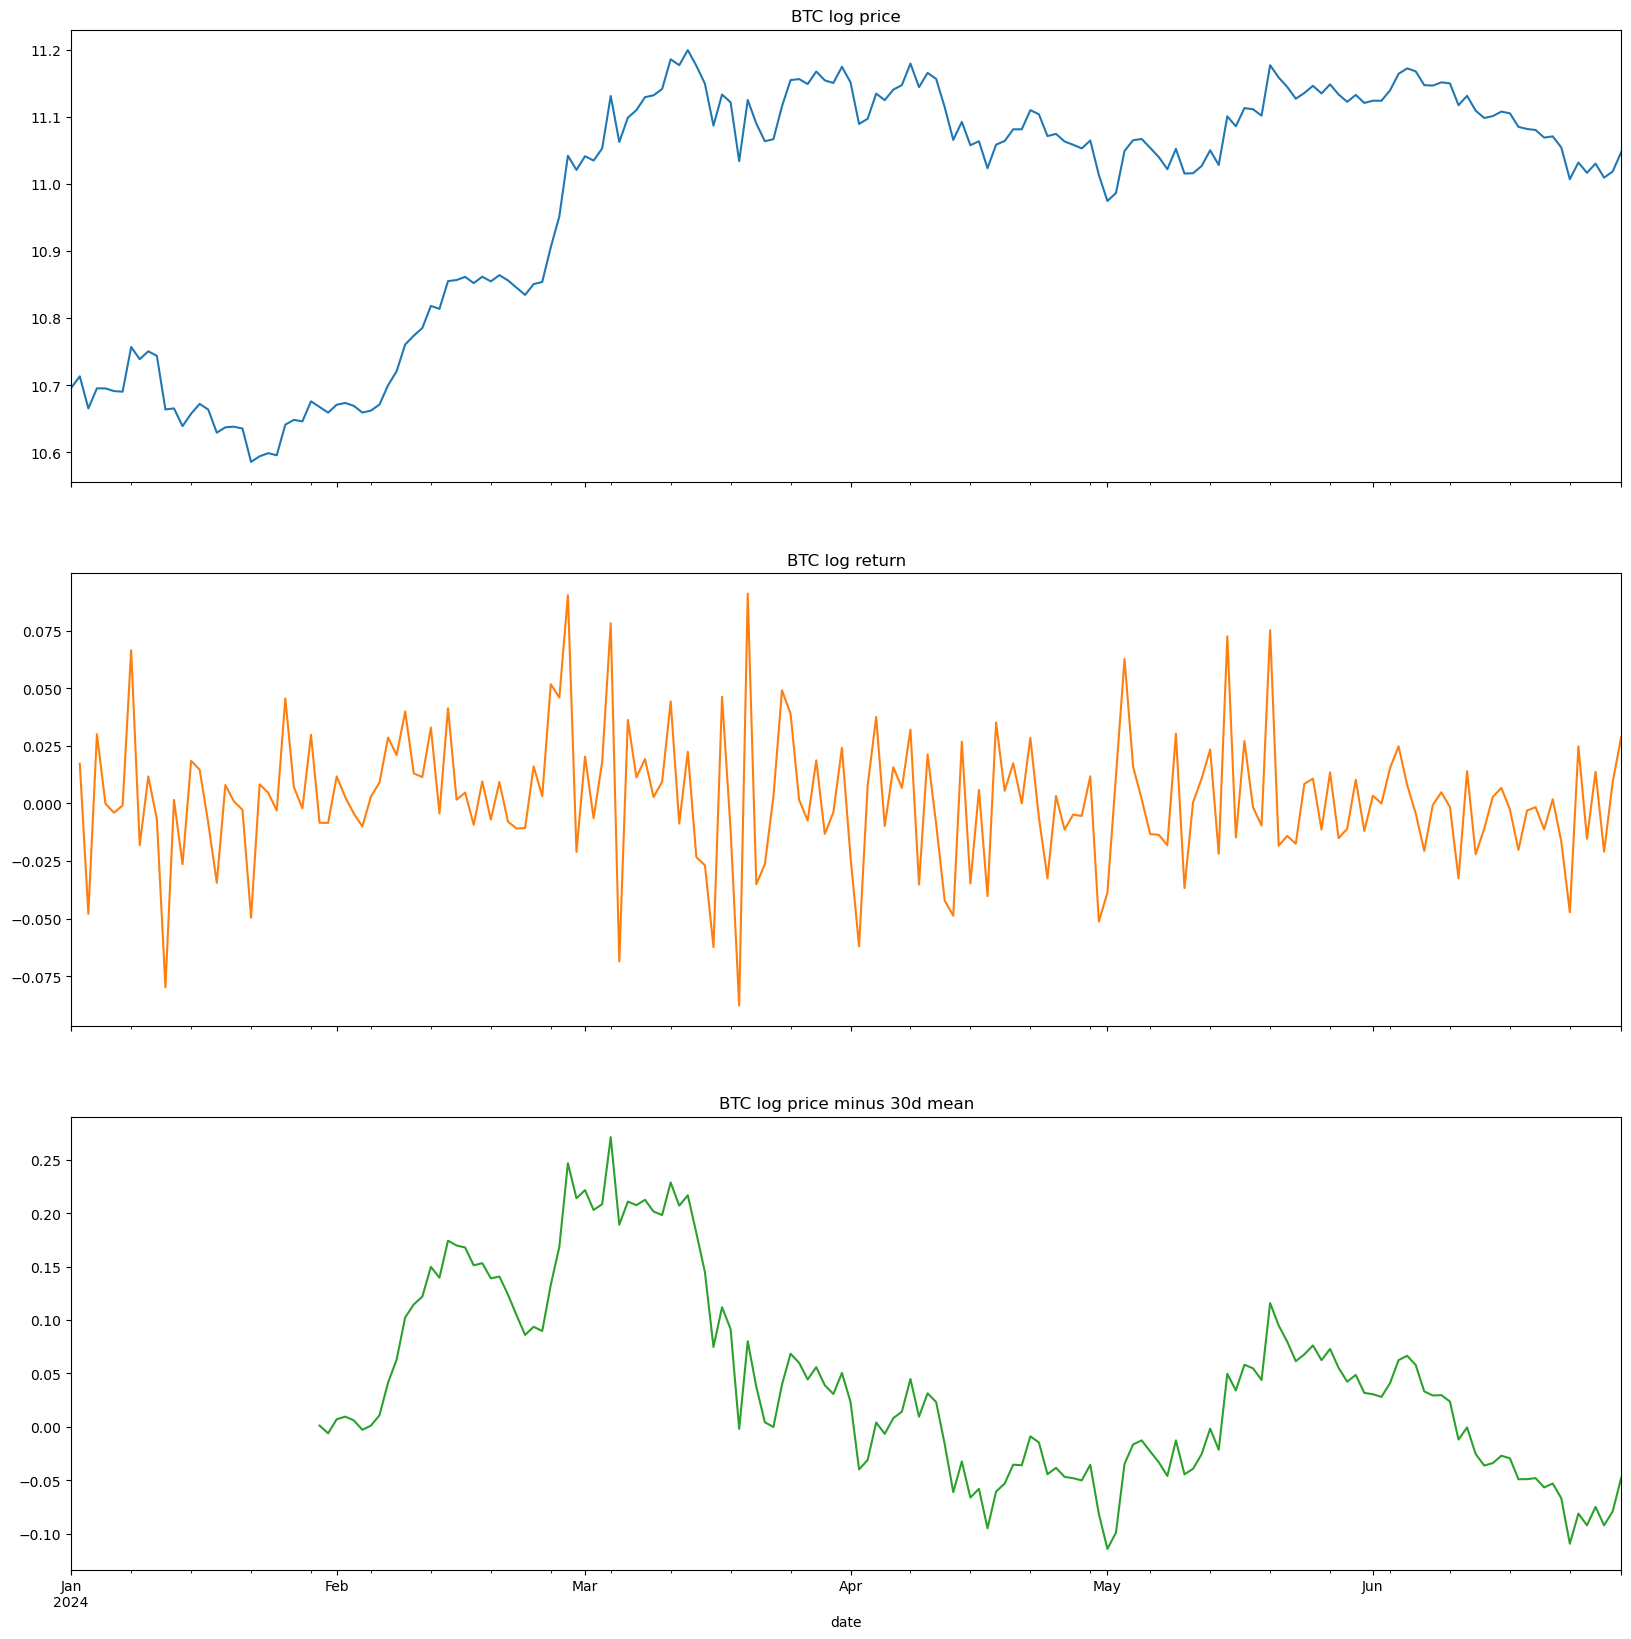

In [4]:
plot_df = pd.concat(
    {
        "log price": log_price,
        "log return": log_return,
        "log price - 30d mean": demeaned_30d,
    },
    axis=1,
)

plot_df.plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC log price", "BTC log return", "BTC log price minus 30d mean"],
    layout=(3, 1),
    legend=False,
);

In [5]:
def run_adf_test(series: pd.Series, name: str, regression: str = "c") -> pd.Series:
    """Run ADF on one series and return a compact summary."""
    cleaned = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, critical_values, icbest = adfuller(
        cleaned,
        regression=regression,
        autolag="AIC",
    )
    return pd.Series(
        {
            "series": name,
            "adf_stat": stat,
            "p_value": pvalue,
            "used_lag": usedlag,
            "n_obs": nobs,
            "crit_1pct": critical_values["1%"],
            "crit_5pct": critical_values["5%"],
            "crit_10pct": critical_values["10%"],
            "reject_5pct": pvalue < 0.05,
        }
    )

In [6]:
results = pd.DataFrame(
    [run_adf_test(series, name) for name, series in series_dict.items()]
).set_index("series")

results

,adf_stat,p_value,used_lag,n_obs,crit_1pct,crit_5pct,crit_10pct,reject_5pct
series,,,,,,,,
BTC close,-1.499190,0.533912,1,180,-3.467211,-2.877735,-2.575403,False
BTC log price,-1.451673,0.557269,1,180,-3.467211,-2.877735,-2.575403,False
BTC log return,-15.496686,0.000000,0,180,-3.467211,-2.877735,-2.575403,True
BTC log price minus 30d mean,-1.510344,0.528388,1,151,-3.474416,-2.880878,-2.577081,False


,adf_stat,p_value,used_lag,n_obs,crit_1pct,crit_5pct,crit_10pct,reject_5pct
series,,,,,,,,
BTC close,-1.499190,0.533912,1,180,-3.467211,-2.877735,-2.575403,False
BTC log price,-1.451673,0.557269,1,180,-3.467211,-2.877735,-2.575403,False
BTC log return,-15.496686,0.000000,0,180,-3.467211,-2.877735,-2.575403,True
BTC log price minus 30d mean,-1.510344,0.528388,1,151,-3.474416,-2.880878,-2.577081,False


In [7]:
summary_df = results.copy()
summary_df["verdict_5pct"] = np.where(
    summary_df["reject_5pct"],
    "reject unit root",
    "fail to reject unit root",
)
summary_df[["adf_stat", "p_value", "used_lag", "n_obs", "verdict_5pct"]]

,adf_stat,p_value,used_lag,n_obs,verdict_5pct
series,,,,,
BTC close,-1.499190,0.533912,1,180,fail to reject unit root
BTC log price,-1.451673,0.557269,1,180,fail to reject unit root
BTC log return,-15.496686,0.000000,0,180,reject unit root
BTC log price minus 30d mean,-1.510344,0.528388,1,151,fail to reject unit root


,adf_stat,p_value,used_lag,n_obs,verdict_5pct
series,,,,,
BTC close,-1.499190,0.533912,1,180,fail to reject unit root
BTC log price,-1.451673,0.557269,1,180,fail to reject unit root
BTC log return,-15.496686,0.000000,0,180,reject unit root
BTC log price minus 30d mean,-1.510344,0.528388,1,151,fail to reject unit root


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_df["p_value"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color=np.where(summary_df["reject_5pct"], "tab:green", "tab:red"),
)
axes[0].axvline(0.05, color="black", linestyle="--", linewidth=1, label="5% threshold")
axes[0].set_title("ADF p-values by transformed series")
axes[0].set_xlabel("p-value")
axes[0].legend()

stat_plot = summary_df[["adf_stat", "crit_5pct"]].sort_values("adf_stat")
stat_plot.plot(kind="bar", ax=axes[1], color=["tab:blue", "tab:orange"])
axes[1].set_title("ADF statistic versus 5% critical value")
axes[1].set_ylabel("test statistic")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout();


In [ ]:
rolling_window = 60
rolling_adf = (
    log_price
    .rolling(rolling_window)
    .apply(lambda window: adfuller(window, regression="c", autolag="AIC")[1], raw=False)
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 4))
rolling_adf.plot(ax=ax, color="tab:purple", linewidth=2)
ax.axhline(0.05, color="black", linestyle="--", linewidth=1, label="5% threshold")
ax.set_title(f"Rolling {rolling_window}-day ADF p-value on BTC log price")
ax.set_ylabel("ADF p-value")
ax.legend()
plt.tight_layout();


## Interpretation

Typical outcomes are:

- `BTC close` and `BTC log price`: usually fail to reject the unit-root null, so they look non-stationary;
- `BTC log return`: often rejects the unit-root null, consistent with stationary fluctuations around zero;
- `BTC log price minus 30d mean`: often looks much more mean-reverting than the raw price.

For mean-reversion trading, the ADF test is usually more informative on a spread, residual, or detrended series than on the raw crypto price itself.